In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [8]:
# ==============================================================================
# FASE 0: CONFIGURAZIONE E CARICAMENTO DATI (BASE)
# ==============================================================================

# Definisce il percorso per l'accesso ai file
DATA_PATH = Path('../data')

# BASE_DIR non è strettamente necessaria se usi solo DATA_PATH, 
# ma la definiamo per completezza se devi accedere ad altri file nella radice.
BASE_DIR = Path('..') # Risale di un livello

print(f"Directory Base del Progetto: {BASE_DIR.resolve()}")
print(f"Percorso Dati: {DATA_PATH.resolve()}")

START_YEAR = 2014
END_YEAR = 2024

# --- Definizione delle Colonne Essenziali ---
# Questo set è stato scelto per l'alta coerenza tra gli anni.
REQUIRED_COLS_STATS = [
    'w_ace', 'l_ace', 'w_df', 'l_df',
    'w_svpt', 'l_svpt',
    'w_1stIn', 'l_1stIn', 'w_1stWon', 'l_1stWon',
    'w_2ndWon', 'l_2ndWon',
    'w_bpSaved', 'l_bpSaved', 'w_bpFaced', 'l_bpFaced'
]
REQUIRED_COLS_RANK = ['winner_rank', 'loser_rank', 'surface']
REQUIRED_ALL = REQUIRED_COLS_STATS + REQUIRED_COLS_RANK

# Tutte le colonne da caricare
INITIAL_COLS = ['tourney_id', 'winner_id', 'loser_id'] + REQUIRED_ALL

# --- Caricamento e Unione dei Dati ---
matches_list = []
found_files_count = 0
skipped_files = []

print(f"--- Inizio Caricamento Dati ({START_YEAR}-{END_YEAR}) ---")
print(f"Cartella di ricerca: {DATA_PATH}")

all_match_files = sorted(list(DATA_PATH.glob('atp_matches_*.csv')))

if not all_match_files:
    raise FileNotFoundError(f"Nessun file 'atp_matches_*.csv' trovato in {DATA_PATH}. Controlla i nomi dei file.")

for match_file in all_match_files:
    try:
        df = pd.read_csv(match_file, low_memory=False)
        current_cols = df.columns.tolist()
        missing_cols = [col for col in INITIAL_COLS if col not in current_cols]
        
        if not missing_cols:
            # CASO 1: File COMPLETO
            matches_list.append(df[INITIAL_COLS])
            found_files_count += 1
        else:
            # CASO 2: Logica di RECUPERO (più esplicita)
            
            # 1. Identifica le colonne CHIAVE non statistiche che mancano
            critical_missing = [
                col for col in INITIAL_COLS 
                if col not in current_cols and col not in REQUIRED_COLS_STATS
            ]

            if critical_missing:
                # Se mancano ID, RANK o SURFACE, SALTA
                skipped_files.append(f"{match_file.name} (SALTO: Mancano colonne CRITICHE: {', '.join(critical_missing)})")
            else:
                # Altrimenti, aggiunge le colonne statistiche mancanti (con NaN) per recuperare l'anno
                for col in missing_cols:
                    df[col] = np.nan
                
                matches_list.append(df[INITIAL_COLS])
                found_files_count += 1
                
                skipped_files.append(f"{match_file.name} (RECUPERO: Aggiunte e riempite con NaN le colonne: {', '.join(missing_cols)})")

    except Exception as e:
        skipped_files.append(f"{match_file.name} (ERRORE di lettura: {e})")

# Unione e pulizia finale
if not matches_list:
    raise FileNotFoundError("Nessun match valido è stato caricato. Interrompendo l'esecuzione.")

full_df = pd.concat(matches_list, ignore_index=True)

initial_rows = len(full_df)
# Rimuove le righe dove manca almeno un valore tra le colonne essenziali
full_df.dropna(subset=REQUIRED_ALL, inplace=True)
dropped_rows = initial_rows - len(full_df)

print(f"\nSUCCESSO: Dataset Integrato e Pulito con {len(full_df)} partite complete.")
print(f"NOTA: Rimosse {dropped_rows} righe con statistiche mancanti (dopo l'unione).")

if skipped_files:
    print(f"\nATTENZIONE: Log di Caricamento/Recupero:")
    for sf in skipped_files:
        print(f"- {sf}")



Directory Base del Progetto: C:\Users\simon\Desktop\Fundamentals_Of_AI_MOD3\Progetto
Percorso Dati: C:\Users\simon\Desktop\Fundamentals_Of_AI_MOD3\Progetto\data
--- Inizio Caricamento Dati (2014-2024) ---
Cartella di ricerca: ..\data

SUCCESSO: Dataset Integrato e Pulito con 28887 partite complete.
NOTA: Rimosse 1686 righe con statistiche mancanti (dopo l'unione).


In [9]:

# ------------------------------------------------------------------------------
# FASE 1: FEATURE ENGINEERING (Logica Favorito vs Sfavorevole) - FORMA BASE
# ------------------------------------------------------------------------------

# Creazione di un nuovo DataFrame per le feature finali
final_df = pd.DataFrame()

# 1. Determinazione del Favorito
# Il favorito è chi ha il rank (numero) inferiore
full_df['is_winner_favorite'] = full_df['winner_rank'] < full_df['loser_rank']

# --- A. Risultato del Favorito (Variabile Target) ---
# 1 = Favorito ha vinto, 0 = Favorito ha perso (Sconfitta)
final_df['Risultato_Favorevole'] = np.where(full_df['is_winner_favorite'] == True, 'Vittoria', 'Sconfitta')

# --- B. Nodo Contesto: Superficie ---
final_df['Superficie'] = full_df['surface'].astype(str)

# --- C. Nodo Status: Differenza di Ranking ---

# La differenza di rank deve essere sempre: Rank_Sfavorevole - Rank_Favorito
# Se il vincitore è il favorito: Diff = loser_rank - winner_rank
# Se il perdente è il favorito: Diff = winner_rank - loser_rank
final_df['Diff_Rank'] = np.where(
    full_df['is_winner_favorite'] == True,
    full_df['loser_rank'] - full_df['winner_rank'],
    full_df['winner_rank'] - full_df['loser_rank']
)

# ------------------------------------------------------------------------------
# --- D. Nodi Performance: Differenze di Statistiche ---
# La logica è sempre: Statistica del Favorito - Statistica dello Sfavorevole

# Definiamo le condizioni per facilitare i calcoli
cond_fav_is_winner = full_df['is_winner_favorite'] == True
cond_fav_is_loser = full_df['is_winner_favorite'] == False # Il perdente è il favorito

# 1. Diff_Ace (Ace_Fav - Ace_Sfav)
final_df['Diff_Ace'] = np.where(
    cond_fav_is_winner,
    full_df['w_ace'] - full_df['l_ace'], # w_ace è del Fav, l_ace è dello Sfav
    full_df['l_ace'] - full_df['w_ace']  # l_ace è del Fav, w_ace è dello Sfav
)

# 2. Diff_DF (DF_Fav - DF_Sfav)
final_df['Diff_DF'] = np.where(
    cond_fav_is_winner,
    full_df['w_df'] - full_df['l_df'],
    full_df['l_df'] - full_df['w_df']
)

# 3. Percentuale Vinta Totale al Servizio (Metrica Derivata)

# Calcolo la percentuale vinta al servizio per entrambi i giocatori
full_df['w_service_win_perc'] = (full_df['w_1stWon'] + full_df['w_2ndWon']) / full_df['w_svpt']
full_df['l_service_win_perc'] = (full_df['l_1stWon'] + full_df['l_2ndWon']) / full_df['l_svpt']

# Diff_ServiceWin (ServiceWin%_Fav - ServiceWin%_Sfav)
final_df['Diff_ServiceWinPerc'] = np.where(
    cond_fav_is_winner,
    full_df['w_service_win_perc'] - full_df['l_service_win_perc'],
    full_df['l_service_win_perc'] - full_df['w_service_win_perc']
)

# Correzione del FutureWarning e rimozione di NaN/Inf
# Correggiamo i valori infiniti (che derivano da divisioni per zero)
final_df['Diff_ServiceWinPerc'] = final_df['Diff_ServiceWinPerc'].replace([np.inf, -np.inf], np.nan)
# Rimuoviamo le righe dove la Diff_ServiceWinPerc è NaN (a causa della divisione per zero in svpt)
final_df.dropna(subset=['Diff_ServiceWinPerc'], inplace=True)


# DataFrame finale per la modellazione
data_numerica_pronta = final_df[[
    'Superficie', 
    'Diff_Rank', 
    'Diff_Ace', 
    'Diff_DF', 
    'Diff_ServiceWinPerc', 
    'Risultato_Favorevole'
]].copy()

print("\n--- FASE 1 COMPLETATA: DataFrame Numerico Pronto ---")
print("Questo DataFrame contiene i dati puliti e le differenze Favorevole-Sfavorevole.")
print("\nEsempio di Dati (Numerici):")
print(data_numerica_pronta.head())



--- FASE 1 COMPLETATA: DataFrame Numerico Pronto ---
Questo DataFrame contiene i dati puliti e le differenze Favorevole-Sfavorevole.

Esempio di Dati (Numerici):
  Superficie  Diff_Rank  Diff_Ace  Diff_DF  Diff_ServiceWinPerc  \
0       Hard       97.0      -4.0     -4.0             0.065175   
1       Hard       26.0       3.0     -2.0            -0.026328   
2       Hard       17.0     -14.0     -1.0            -0.138205   
3       Hard       72.0     -18.0      2.0            -0.125581   
4       Hard       20.0       2.0      2.0            -0.065128   

  Risultato_Favorevole  
0             Vittoria  
1            Sconfitta  
2            Sconfitta  
3            Sconfitta  
4             Vittoria  



--- FASE 2 INIZIO: Analisi Esplorativa dei Dati (EDA) ---

1. Distribuzione Risultato (Vittoria/Sconfitta) per Superficie:
Risultato_Favorevole  Sconfitta  Vittoria
Superficie                               
Carpet                    28.57     71.43
Clay                      34.94     65.06
Grass                     35.93     64.07
Hard                      35.09     64.91


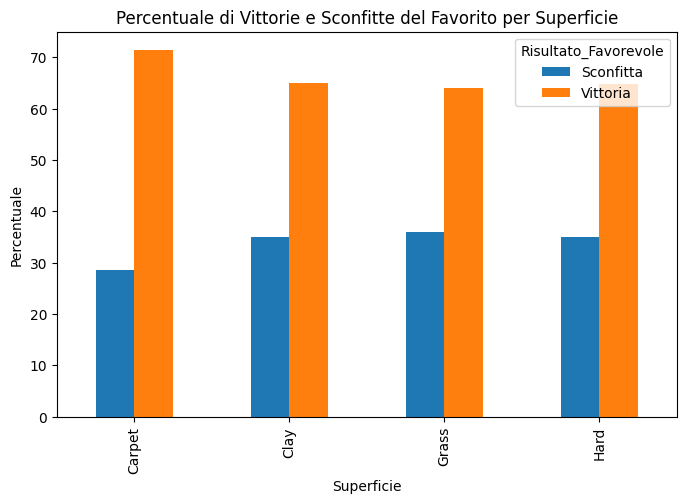

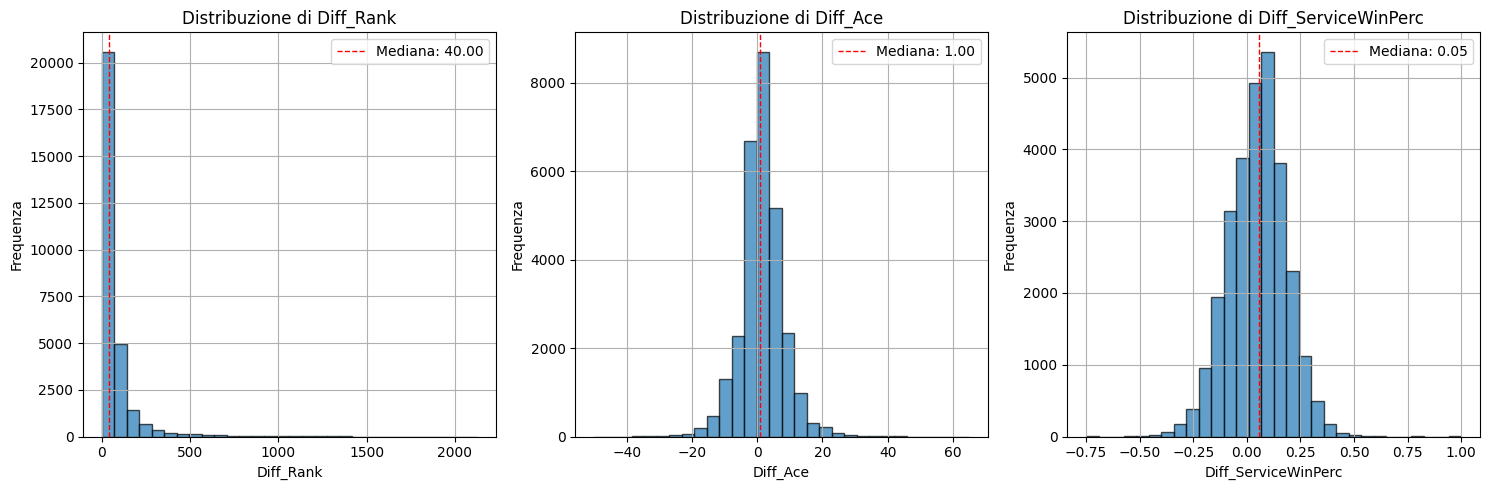


3. Analisi dell'impatto di Diff_ServiceWinPerc sul Risultato:


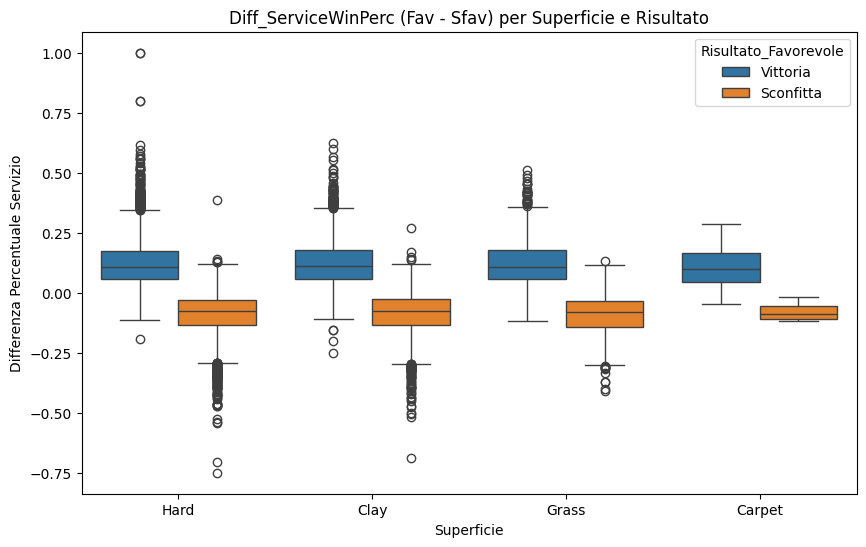


--- FASE 2 COMPLETATA: Analisi Visiva Eseguita ---


In [10]:

# ==============================================================================
# FASE 2: EDA (ANALISI ESPLORATIVA DEI DATI)
# ==============================================================================

print("\n--- FASE 2 INIZIO: Analisi Esplorativa dei Dati (EDA) ---")

# 1. Analisi della Variabile Target per Superficie
print("\n1. Distribuzione Risultato (Vittoria/Sconfitta) per Superficie:")
# Tabella di contingenza per capire la frequenza degli upset su diverse superfici
contingency_table = pd.crosstab(
    data_numerica_pronta['Superficie'], 
    data_numerica_pronta['Risultato_Favorevole'], 
    normalize='index'
) * 100
print(contingency_table.round(2))
# Visualizzazione per confermare l'importanza di 'Superficie'
contingency_table.plot(kind='bar', figsize=(8, 5))
plt.title('Percentuale di Vittorie e Sconfitte del Favorito per Superficie')
plt.ylabel('Percentuale')
plt.show() # Triggers the display of the plot

# 2. Analisi della Distribuzione delle Differenze (per la Discretizzazione)
COLS_TO_ANALYZE = ['Diff_Rank', 'Diff_Ace', 'Diff_ServiceWinPerc']
plt.figure(figsize=(15, 5))

for i, col in enumerate(COLS_TO_ANALYZE):
    plt.subplot(1, 3, i + 1)
    # Istogramma della distribuzione
    data_numerica_pronta[col].hist(bins=30, edgecolor='black', alpha=0.7)
    
    # Calcolo di media e mediana per orientamento
    median_val = data_numerica_pronta[col].median()
    
    plt.axvline(median_val, color='red', linestyle='dashed', linewidth=1, label=f'Mediana: {median_val:.2f}')
    plt.title(f'Distribuzione di {col}')
    plt.xlabel(f'{col}')
    plt.ylabel('Frequenza')
    plt.legend()

plt.tight_layout()
plt.show() # Triggers the display of the plot

# 3. Analisi di Boxplot (Impatto su Risultato e Superficie)
print("\n3. Analisi dell'impatto di Diff_ServiceWinPerc sul Risultato:")
# Box plot per visualizzare come le statistiche si comportano quando il favorito perde (upset)
plt.figure(figsize=(10, 6))
import seaborn as sns # Si consiglia seaborn per boxplot eleganti
# Installare seaborn se non presente: pip install seaborn
sns.boxplot(
    x='Superficie', 
    y='Diff_ServiceWinPerc', 
    hue='Risultato_Favorevole', 
    data=data_numerica_pronta
)
plt.title('Diff_ServiceWinPerc (Fav - Sfav) per Superficie e Risultato')
plt.ylabel('Differenza Percentuale Servizio')
plt.show() # Triggers the display of the plot 

print("\n--- FASE 2 COMPLETATA: Analisi Visiva Eseguita ---")